In [1]:
import json
from dataclasses import dataclass, asdict
from dataclasses_json import dataclass_json
from typing import Optional
import pandas as pd
from matplotlib import pyplot as plt


In [8]:
@dataclass_json
@dataclass
class MetaItem:
    Size: Optional[str] = None
    steps: Optional[int] = None
    prompt: Optional[str] = None
    negativePrompt: Optional[str] = None


@dataclass_json
@dataclass
class ImageItem:
    id: int
    width: int
    height: int
    nsfw: bool
    meta: Optional[MetaItem] = None


@dataclass_json
@dataclass
class DataSet:
    items: list[ImageItem]


def read_dataset(start=0, end=1):
    ret = []
    for i in range(start, end):
        with open(f"data_civitai/civitai_database/231112_p{i}.json") as f:
            a = "".join(f.readlines())
        data = DataSet.from_json(a)
        ret += data.items
    return ret


imageItems = read_dataset(0, 20)
print(len(imageItems))


2000


In [9]:
# for item in dataset.items:
#     item.to_dict()
imageItems[0].to_dict()
    

{'id': 127497,
 'width': 768,
 'height': 1152,
 'nsfw': False,
 'meta': {'Size': '512x768',
  'steps': 25,
  'prompt': 'best quality, (photorealistic:1.4), 1girl, (black shirt:1.2),  (grey long pants:1.2),(white suspenders:1.4), perfect female figure, full body, from back, white background, short hair, slim',
  'negativePrompt': 'nsfw, paintings, sketches, (worst quality:2), (low quality:2), (normal quality:2), lowres,  ((monochrome)), ((grayscale))'}}

In [11]:
df = pd.json_normalize([asdict(item) for item in imageItems])
print("Before filter #:", len(df))
df = df[df["nsfw"] == False]
print("After NSFW filter #:", len(df))
df = df[df["meta.Size"].isna() == False]
print("After Meta shape filter #:", len(df))
df = df.iloc[:300]
df


Before filter #: 2000
After NSFW filter #: 702
After Meta shape filter #: 469


,id,width,height,nsfw,meta.Size,meta.steps,meta.prompt,meta.negativePrompt,meta
0,127497,768,1152,False,512x768,25.0,"best quality, (photorealistic:1.4), 1girl, (bl...","nsfw, paintings, sketches, (worst quality:2), ...",NaN
2,295008,1152,1728,False,768x1152,30.0,"(RAW photo, best quality), (realistic, photo-r...","paintings, sketches, (worst quality:2), (low q...",NaN
9,2008378,1024,1024,False,1024x1024,46.0,Amazing detailed photography of a perfect beau...,"(worst quality, low quality, illustration, 3d,...",NaN
16,256477,1024,1536,False,512x768,20.0,"(RAW photo, best quality), (realistic, photo-r...","(worst quality:1.4), (low quality:1.4), (monoc...",NaN
17,107787,896,1536,False,448x768,20.0,"<lora:koreanDollLikeness_v10:0.3>,<lora:taiwan...","EasyNegative, paintings, sketches, (worst qual...",NaN
...,...,...,...,...,...,...,...,...,...
1249,130106,464,512,False,464x512,30.0,"(cum on face, cum string:1.2) <lora:cumshot_49:1>",None,NaN
1257,114071,896,1344,False,896x1344,30.0,"masterpiece, (photorealistic:1.4), best qualit...","(painting by bad-artist-anime:0.9), (painting ...",NaN
1258,1858744,1120,1408,False,512x640,30.0,"(masterpiece), (extremely intricate:1.3),, (re...","BadDream, (UnrealisticDream:1.3)",NaN
1266,2112738,1152,2016,False,768x1344,36.0,Drawing inspiration from modern masters like Y...,"monochrome, chibi,simple,exaggerated,clich sho...",NaN


In [12]:
import matplotlib
import numpy as np
def draw_heatmap(x, y):
    X_refine = []
    Y_refine = []
    X_outbound = []
    Y_outbound = []

    print(f"{x.min()=} {y.min()=} {x.max()=} {y.max()=}")
    xy_min = 256
    xy_max = 1024
    for item1, item2 in zip(x, y):
        # item1 = x[i]
        # item2 = y[i]
        if xy_min <= item1 <= xy_max and xy_min <= item2 <= xy_max:
            X_refine.append(item1)
            Y_refine.append(item2)
        else:
            X_outbound.append(item1)
            Y_outbound.append(item2)

    fig, ax = plt.subplots(
        figsize=(4, 3), layout="constrained"
    )

    # h=ax.hist2d(X_refine,Y_refine,bins=60,cmin=0) # ,norm=LogNorm())

    h = ax.hist2d(
        # x, y, 
        X_refine, Y_refine, 
        range=[[xy_min, xy_max]] * 2, bins=(xy_max - xy_min) // 64, cmin=1, 
        cmap="twilight",
        vmin=1, vmax = 1000, 
        # norm=matplotlib.colors.Normalize(),
        # cmap="GnBu"
        # cmap="Blues"
    )  # ,norm=LogNorm())
    max_cnt = np.nanmax(h[0])
    print(h, max_cnt, max_cnt/len(X_refine))
    # ax.set_facecolor("lightgray")
    # Get range of colorbar

    # Set colorbar range and labels
    fig.colorbar(h[3], ax=ax, format=matplotlib.ticker.FuncFormatter(lambda x, pos: f'{x/len(X_refine)*100:.1f}%'))
    # fig.suptitle("Height-width Hist2D")
    fig.supylabel("Width")
    fig.supxlabel("Height")
    # fig.savefig("./many4.png")
    print(f"{X_outbound=}\n{Y_outbound=}")
    plt.show()


x.min()=224 y.min()=224 x.max()=6144 y.max()=6144
        x     y  cnt
0     224   224    1
1     300   450    1
2     368   512    1
3     384   640    1
4     384   896    1
..    ...   ...  ...
107  2624  3456    1
108  2816  4224    1
109  2880  3840    1
110  3072  4800    1
111  6144  6144    1

[112 rows x 3 columns]
X_outbound=[]
Y_outbound=[]


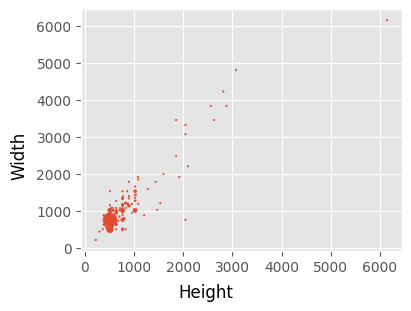

In [13]:
import matplotlib
import numpy as np
def draw_bubble(x, y):
    X_refine = []
    Y_refine = []
    X_outbound = []
    Y_outbound = []

    print(f"{x.min()=} {y.min()=} {x.max()=} {y.max()=}")
    xy_min = 0
    xy_max = 10000
    for item1, item2 in zip(x, y):
        # item1 = x[i]
        # item2 = y[i]
        if xy_min <= item1 <= xy_max and xy_min <= item2 <= xy_max:
            X_refine.append(item1)
            Y_refine.append(item2)
        else:
            X_outbound.append(item1)
            Y_outbound.append(item2)

    plt.style.use('ggplot')
    fig, ax = plt.subplots(
        figsize=(4, 3), layout="constrained"
    )
    df = pd.DataFrame({"x": X_refine, "y": Y_refine, 'cnt':1}).groupby(['x', 'y']).count()
    df = pd.DataFrame(df.to_records(), columns=df.index.names + list(df.columns))
    print(df)
    df.to_csv("bubble.csv")
    # return 
    ax.scatter('x', 'y', s='cnt', data=df)
    fig.supylabel("Width")
    fig.supxlabel("Height")
    # fig.savefig("./many4.png")
    print(f"{X_outbound=}\n{Y_outbound=}")
    plt.show()

meta_shape = df["meta.Size"][~df["meta.Size"].isna()]
# meta_shape.str.split('x').str[0].astype(int).hist(bins=100)
# draw_heatmap(meta_shape.str.split('x').str[0].astype(int), meta_shape.str.split('x').str[1].astype(int))
meta_x = meta_shape.str.split("x").str[0].astype(int)
meta_y = meta_shape.str.split("x").str[1].astype(int)
# draw_heatmap(meta_x, meta_y)
draw_bubble(meta_x, meta_y)


x.min()=384 y.min()=480 x.max()=6144 y.max()=7584
X_outbound=[768, 1152, 896, 1160, 1024, 1024, 896, 896, 512, 1513, 1280, 768, 864, 1024, 1024, 1024, 768, 512, 1024, 1024, 896, 816, 1208, 1024, 1080, 768, 716, 1024, 1024, 1024, 1024, 1024, 832, 1024, 1024, 1024, 768, 992, 2560, 1024, 896, 1024, 568, 1024, 2048, 2048, 1280, 4096, 1024, 1536, 2048, 1280, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 768, 1024, 1024, 1024, 1024, 1024, 800, 1536, 1152, 672, 1088, 3072, 1024, 1536, 2304, 3072, 2880, 768, 896, 896, 1024, 1600, 1024, 1024, 896, 1024, 1440, 896, 1024, 1024, 1024, 1024, 880, 992, 1024, 896, 1024, 1024, 1024, 1024, 1024, 3072, 1024, 896, 614, 534, 864, 800, 1024, 624, 1920, 768, 1024, 1024, 2048, 1840, 1584, 1024, 752, 896, 1024, 1024, 1024, 1024, 1024, 2880, 1536, 1024, 2048, 1280, 1024, 1024, 1056, 1024, 1024, 1856, 944, 1024, 1024, 1024, 1120, 2048, 768, 1024, 1024, 2048, 1536, 1096, 1152, 1024, 920, 1536, 1280, 960, 1024, 1152, 1120, 1280, 1024, 1024, 896, 1024, 2112, 768, 3072

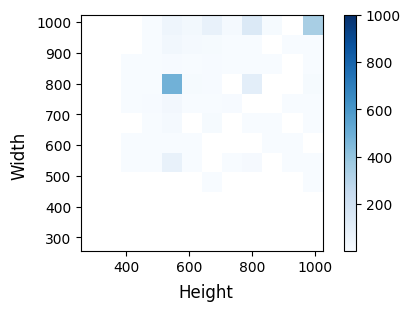

In [70]:
draw_heatmap(df["width"], df["height"])


In [127]:
def analyze_prompt(prompt):
    prompt = prompt.dropna()
    length = prompt.apply(lambda x: len(x.split()) if x is not None else 0)
    print(length.describe())


analyze_prompt(df["meta.prompt"])
analyze_prompt(df["meta.negativePrompt"])


count    981.000000
mean      39.124363
std       43.285276
min        1.000000
25%       17.000000
50%       29.000000
75%       49.000000
max      800.000000
Name: meta.prompt, dtype: float64
count    943.000000
mean      35.352068
std       49.476486
min        0.000000
25%        7.000000
50%       17.000000
75%       41.500000
max      576.000000
Name: meta.negativePrompt, dtype: float64
